<>:19: SyntaxWarning:

invalid escape sequence '\$'

<>:19: SyntaxWarning:

invalid escape sequence '\$'

/var/folders/fl/gpwh4_ws0knfnzjw775cylkw0000gn/T/ipykernel_7222/3273656559.py:19: SyntaxWarning:

invalid escape sequence '\$'

/var/folders/fl/gpwh4_ws0knfnzjw775cylkw0000gn/T/ipykernel_7222/3273656559.py:37: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/fl/gpwh4_ws0knfnzjw775cylkw0000gn/T/ipykernel_7222/3273656559.py:37: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/fl/gpwh4_ws0knfnzjw775cylkw0000

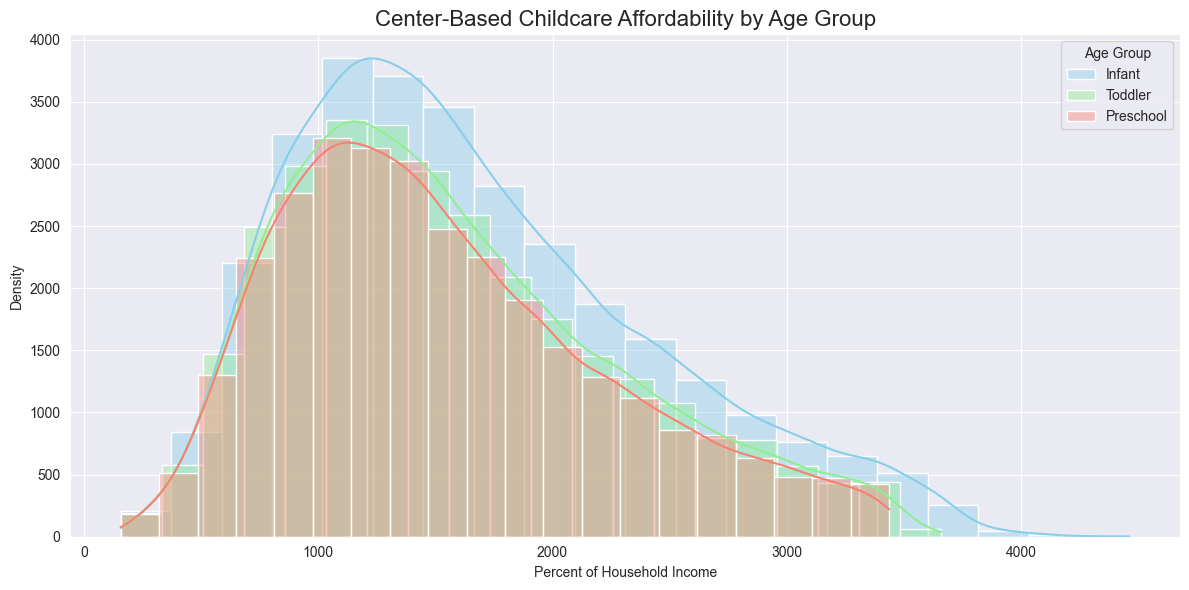

/var/folders/fl/gpwh4_ws0knfnzjw775cylkw0000gn/T/ipykernel_7222/3273656559.py:75: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




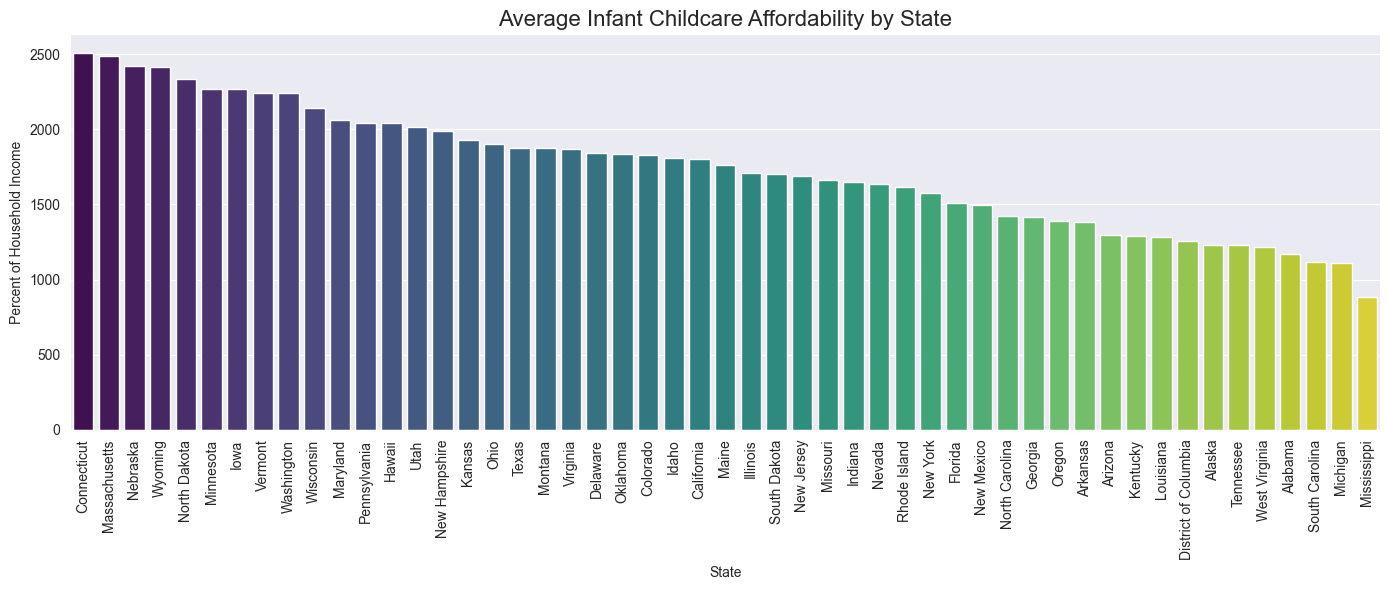

/var/folders/fl/gpwh4_ws0knfnzjw775cylkw0000gn/T/ipykernel_7222/3273656559.py:88: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




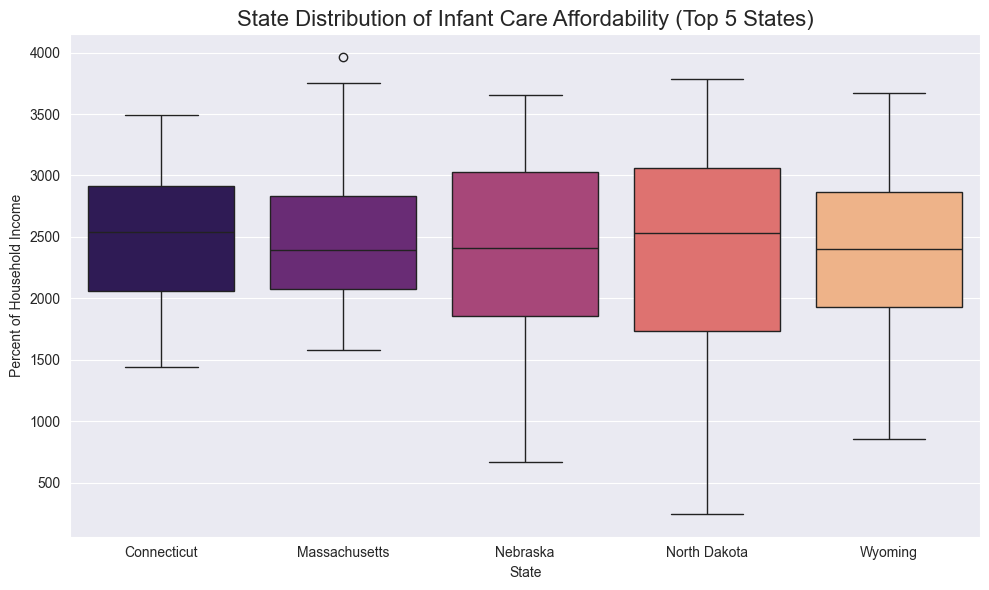

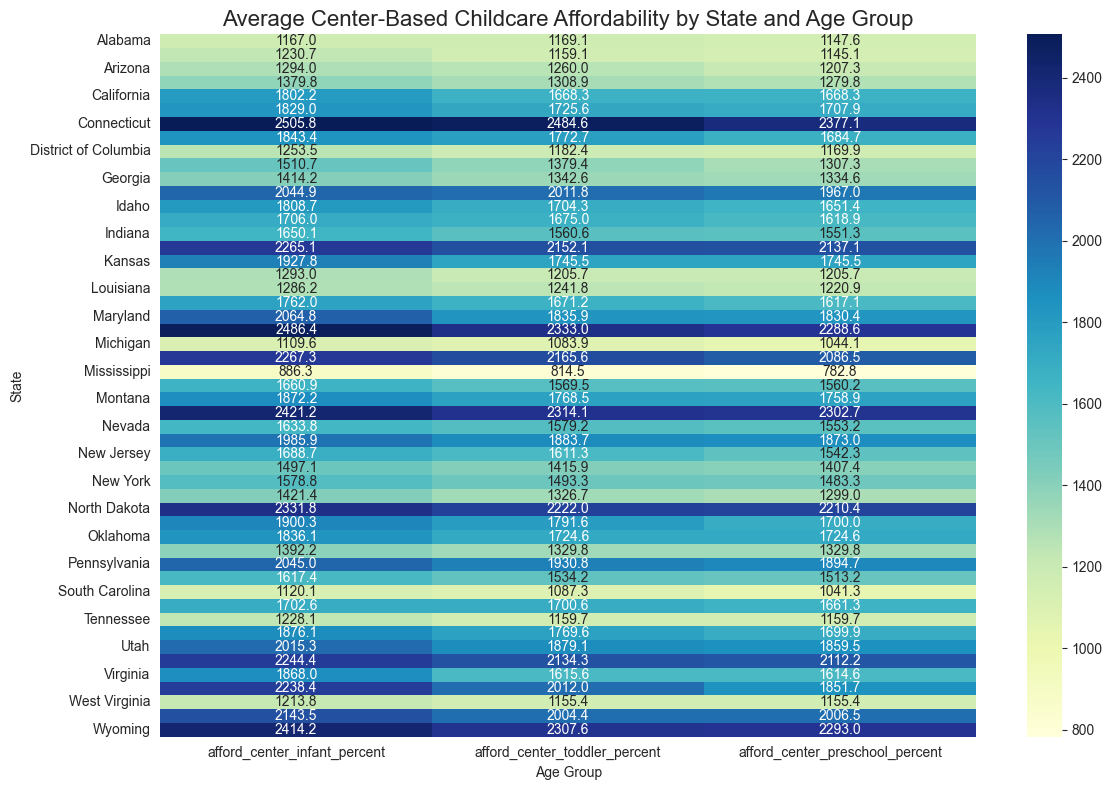

/var/folders/fl/gpwh4_ws0knfnzjw775cylkw0000gn/T/ipykernel_7222/3273656559.py:122: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




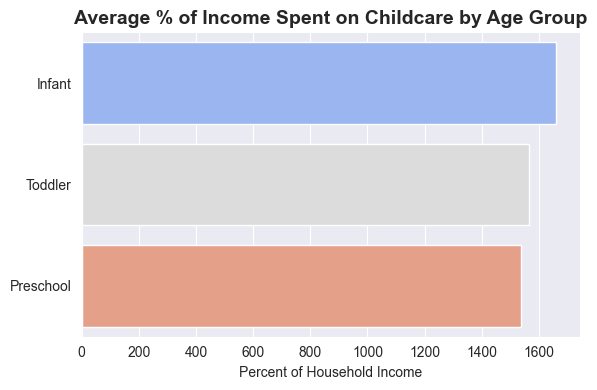

/var/folders/fl/gpwh4_ws0knfnzjw775cylkw0000gn/T/ipykernel_7222/3273656559.py:137: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/var/folders/fl/gpwh4_ws0knfnzjw775cylkw0000gn/T/ipykernel_7222/3273656559.py:143: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




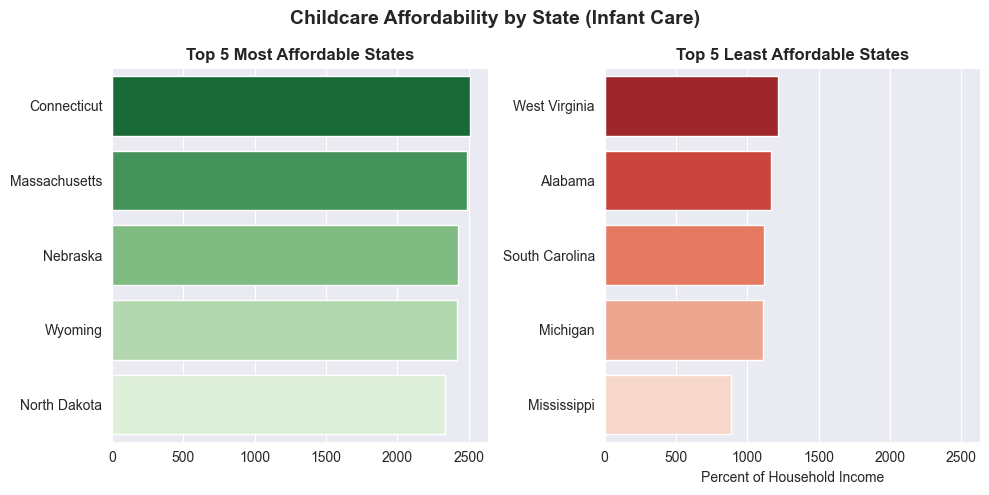


✅ All six visuals created and saved as PNG files:
- graph1_distribution_agegroup.png
- graph2_avg_afford_state.png
- graph3_boxplot_top_states.png
- graph4_heatmap_state_age.png
- graph5_poster_agegroup_bar.png
- graph6_poster_affordable_states.png


In [27]:
# Childcare Affordability Data Visualizations, Megan Pokal

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and Clean Dataset
df = pd.read_csv("national_data_base_of_child_care_prices.csv")

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_', regex=True)

# Convert cost columns to numeric
dollar_cols = ['mfccinfant', 'mfcctoddler', 'mfccpreschool']
for col in dollar_cols:
    if col in df.columns:
        df[col] = df[col].replace('[\$,]', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Handle missing values
df.dropna(how='all', inplace=True)
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna('Unknown')

# Define median income column
median_income_col = 'munr_20to64'
if median_income_col not in df.columns:
    raise KeyError("Expected column 'munr_20to64' not found in dataset.")

# Create affordability columns
for age, cost_col in zip(['infant', 'toddler', 'preschool'], dollar_cols):
    if cost_col in df.columns:
        df[f'afford_center_{age}_percent'] = (df[cost_col] / df[median_income_col]) * 100

# Remove outliers for clarity
for col in ['afford_center_infant_percent', 'afford_center_toddler_percent', 'afford_center_preschool_percent']:
    if col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        df = df[(df[col] >= q1 - 1.5 * iqr) & (df[col] <= q3 + 1.5 * iqr)]

# GRAPH 1: KDE Distribution Plot by Age Group
plt.figure(figsize=(12,6))
age_colors = {'infant': 'skyblue', 'toddler': 'lightgreen', 'preschool': 'salmon'}

for age in ['infant', 'toddler', 'preschool']:
    col = f'afford_center_{age}_percent'
    if col in df.columns:
        sns.histplot(
            df[col].dropna(),
            bins=20,
            kde=True,
            color=age_colors[age],
            label=age.capitalize(),
            alpha=0.4
        )

plt.title('Center-Based Childcare Affordability by Age Group', fontsize=16)
plt.xlabel('Percent of Household Income')
plt.ylabel('Density')
plt.legend(title='Age Group')
plt.tight_layout()
plt.savefig("graph1_distribution_agegroup.png", dpi=300)
plt.show()

# GRAPH 2: Bar Plot of Average Affordability by State
avg_afford_state = df.groupby('state_name')['afford_center_infant_percent'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,6))
sns.barplot(x=avg_afford_state.index, y=avg_afford_state.values, palette='viridis', legend=False)
plt.xticks(rotation=90)
plt.title('Average Infant Childcare Affordability by State', fontsize=16)
plt.ylabel('Percent of Household Income')
plt.xlabel('State')
plt.tight_layout()
plt.savefig("graph2_avg_afford_state.png", dpi=300)
plt.show()

# GRAPH 3: Boxplot of Affordability in Top States
if 'state_name' in df.columns:
    top_states = avg_afford_state.head(5).index
    plt.figure(figsize=(10,6))
    sns.boxplot(
        x='state_name',
        y='afford_center_infant_percent',
        data=df[df['state_name'].isin(top_states)],
        palette='magma'
    )
    plt.title('State Distribution of Infant Care Affordability (Top 5 States)', fontsize=16)
    plt.ylabel('Percent of Household Income')
    plt.xlabel('State')
    plt.tight_layout()
    plt.savefig("graph3_boxplot_top_states.png", dpi=300)
    plt.show()

# GRAPH 4: Heatmap of Affordability by State and Age Group
afford_cols = ['afford_center_infant_percent', 'afford_center_toddler_percent', 'afford_center_preschool_percent']
state_age_afford = df.groupby('state_name')[afford_cols].mean()

plt.figure(figsize=(12,8))
sns.heatmap(state_age_afford, annot=True, fmt=".1f", cmap='YlGnBu')
plt.title('Average Center-Based Childcare Affordability by State and Age Group', fontsize=16)
plt.xlabel('Age Group')
plt.ylabel('State')
plt.tight_layout()
plt.savefig("graph4_heatmap_state_age.png", dpi=300)
plt.show()

# GRAPH 5: Poster Chart 1 – Average % of Income by Age Group
age_means = {
    'Infant': df['afford_center_infant_percent'].mean(),
    'Toddler': df['afford_center_toddler_percent'].mean(),
    'Preschool': df['afford_center_preschool_percent'].mean()
}

plt.figure(figsize=(6,4))
sns.barplot(x=list(age_means.values()), y=list(age_means.keys()), palette='coolwarm')
plt.title('Average % of Income Spent on Childcare by Age Group', fontsize=14, weight='bold')
plt.xlabel('Percent of Household Income')
plt.ylabel('')
plt.tight_layout()
plt.savefig("graph5_poster_agegroup_bar.png", dpi=300)
plt.show()

# GRAPH 6: Poster Chart 2 – Top 5 Most & Least Affordable States
least_affordable = avg_afford_state.tail(5)
most_affordable = avg_afford_state.head(5)

fig, axes = plt.subplots(1, 2, figsize=(10,5), sharex=True)

# Most affordable
sns.barplot(x=most_affordable.values, y=most_affordable.index, ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 5 Most Affordable States', fontsize=12, weight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

# Least affordable
sns.barplot(x=least_affordable.values, y=least_affordable.index, ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 5 Least Affordable States', fontsize=12, weight='bold')
axes[1].set_xlabel('Percent of Household Income')
axes[1].set_ylabel('')

plt.suptitle('Childcare Affordability by State (Infant Care)', fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig("graph6_poster_affordable_states.png", dpi=300)
plt.show()

print("\n✅ All six visuals created and saved as PNG files:")
print("- graph1_distribution_agegroup.png")
print("- graph2_avg_afford_state.png")
print("- graph3_boxplot_top_states.png")
print("- graph4_heatmap_state_age.png")
print("- graph5_poster_agegroup_bar.png")
print("- graph6_poster_affordable_states.png")


Index(['State_Name', 'State_Abbreviation', 'County_Name', 'County_FIPS_Code',
       'StudyYear', 'UNR_16', 'FUNR_16', 'MUNR_16', 'UNR_20to64',
       'FUNR_20to64',
       ...
       'MFCCToddler', 'MFCCToddler_flag', 'MFCCPreschool',
       'MFCCPreschool_flag', '_75FCCInfant', '_75FCCInfant_flag',
       '_75FCCToddler', '_75FCCToddler_flag', '_75FCCPreschool',
       '_75FCCPreschool_flag'],
      dtype='object', length=227)


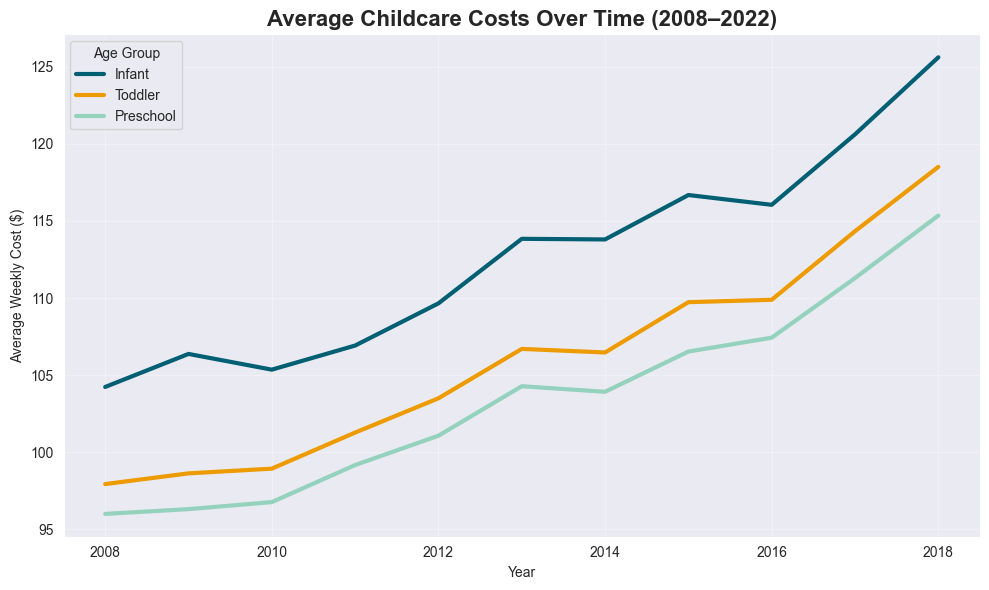

/var/folders/fl/gpwh4_ws0knfnzjw775cylkw0000gn/T/ipykernel_7222/2021822032.py:107: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



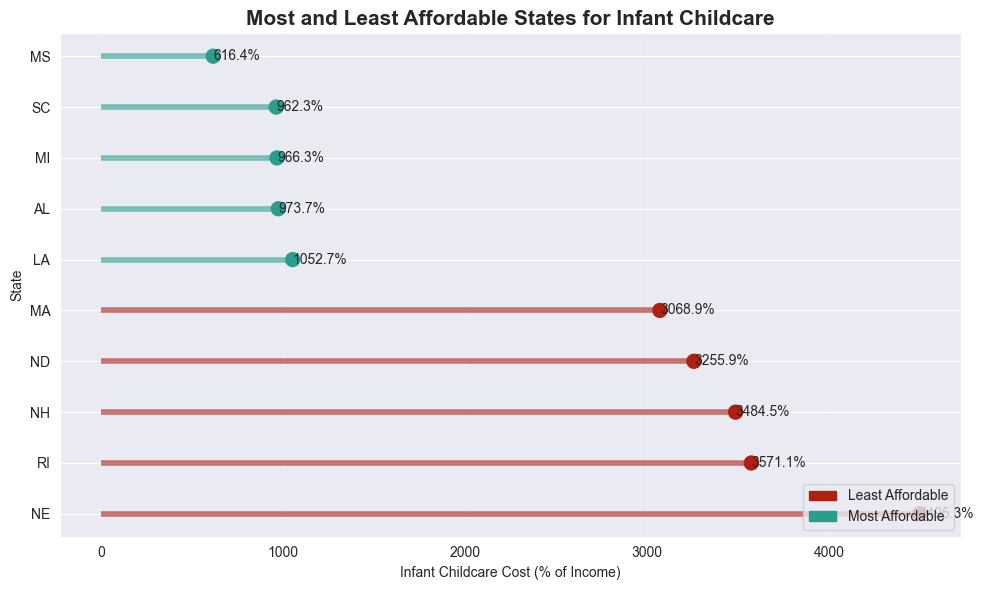

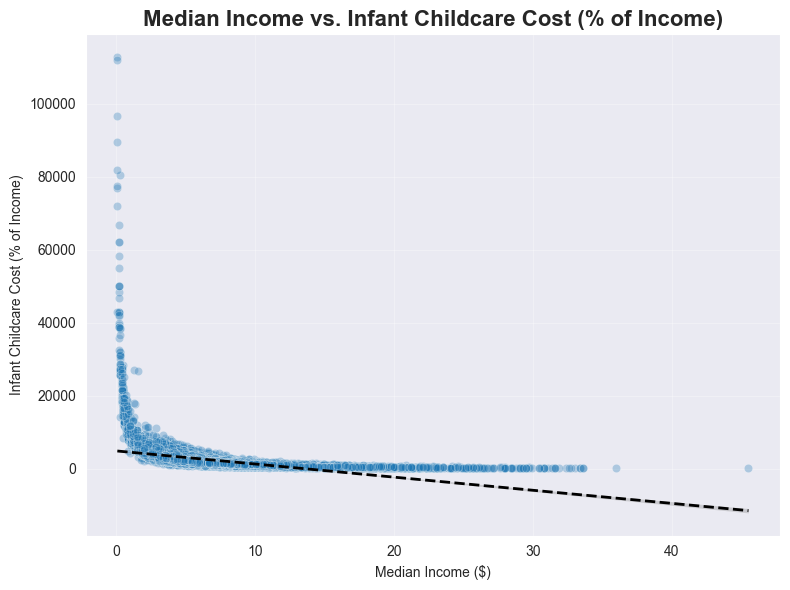

In [28]:
# Medium: Blog Post, Megan Pokal

# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load data
df = pd.read_csv("national_data_base_of_child_care_prices.csv")

# Get column names
print(df.columns)

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_", regex=True)

# Correct cost & income columns based on actual dataset
cost_cols = ["mfccinfant", "mfcctoddler", "mfccpreschool"]
income_col = "munr_20to64"

# Drop rows missing these variables
df = df.dropna(subset=cost_cols + [income_col])

# Convert costs to numeric (remove any stray symbols)
for col in cost_cols:
    df[col] = (
        df[col]
        .replace(r'[\$,]', '', regex=True)
        .astype(float)
    )

# Create affordability columns: childcare cost as % of income
df["afford_infant_percent"] = (df["mfccinfant"] / df[income_col]) * 100
df["afford_toddler_percent"] = (df["mfcctoddler"] / df[income_col]) * 100
df["afford_preschool_percent"] = (df["mfccpreschool"] / df[income_col]) * 100



# VISUAL 1: Line Chart Over Time
plt.figure(figsize=(10,6))
colors = {
    "mfccinfant": "#005f73",
    "mfcctoddler": "#ee9b00",
    "mfccpreschool": "#94d2bd"
}

for col in cost_cols:
    yearly = df.groupby("studyyear")[col].mean()
    plt.plot(
        yearly.index,
        yearly.values,
        label=col.replace("mfcc", "").replace("infant","Infant").replace("toddler","Toddler").replace("preschool","Preschool"),
        linewidth=3,
        color=colors[col]
    )

plt.title("Average Childcare Costs Over Time (2008–2022)", fontsize=16, weight="bold")
plt.xlabel("Year")
plt.ylabel("Average Weekly Cost ($)")
plt.legend(title="Age Group")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("blog_visual1_line_costs_over_time.png", dpi=300)
plt.show()

# VISUAL 2: Choropleth Map by State
# uses state_abbreviation NOT state_name
state_afford = df.groupby("state_abbreviation")["afford_infant_percent"].mean().reset_index()

fig = px.choropleth(
    state_afford,
    locations="state_abbreviation",
    locationmode="USA-states",
    color="afford_infant_percent",
    color_continuous_scale="RdYlGn_r",
    scope="usa",
    title="Infant Childcare Affordability (% of Median Income)",
    labels={"afford_infant_percent": "% of Income"}
)
fig.show()

# VISUAL 3: Most vs Least Affordable States

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Dataset
df = pd.read_csv("national_data_base_of_child_care_prices.csv")

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_", regex=True)

# Drop rows missing key columns
cost_col = "mfccinfant"
income_col = "munr_20to64"
df = df.dropna(subset=[cost_col, income_col])

# Ensure numeric
df[cost_col] = df[cost_col].replace(r'[\$,]', '', regex=True).astype(float)
df[income_col] = df[income_col].replace(r'[\$,]', '', regex=True).astype(float)

# Calculate infant affordability percent by state
state_afford = df.groupby("state_abbreviation")\
    .apply(lambda x: x[cost_col].mean() / x[income_col].mean() * 100)\
    .reset_index(name="afford_infant_percent")

# Select top 5 most affordable and bottom 5 least affordable
most_affordable = state_afford.nsmallest(5, "afford_infant_percent")
least_affordable = state_afford.nlargest(5, "afford_infant_percent")

# Combine for plotting
combined = pd.concat([least_affordable, most_affordable]).reset_index(drop=True)

# Assign affordability type dynamically
combined["affordability_type"] = combined["afford_infant_percent"].apply(
    lambda x: "Least Affordable" if x >= least_affordable["afford_infant_percent"].min() else "Most Affordable"
)

# Sort so least affordable is on top
combined = combined.sort_values("afford_infant_percent", ascending=False).reset_index(drop=True)

# Color mapping
palette = {"Least Affordable": "#ae2012", "Most Affordable": "#2a9d8f"}
colors = combined["affordability_type"].map(palette)

# Plot horizontal lollipop chart
plt.figure(figsize=(10,6))
plt.hlines(y=combined["state_abbreviation"], xmin=0, xmax=combined["afford_infant_percent"],
           color=colors, alpha=0.6, linewidth=4)
plt.scatter(combined["afford_infant_percent"], combined["state_abbreviation"],
            color=colors, s=100)

# Add value labels at the end of each lollipop
for i, (value, state) in enumerate(zip(combined["afford_infant_percent"], combined["state_abbreviation"])):
    plt.text(value + 0.3, i, f"{value:.1f}%", va='center')

plt.xlabel("Infant Childcare Cost (% of Income)")
plt.ylabel("State")
plt.title("Most and Least Affordable States for Infant Childcare", fontsize=15, weight="bold")
plt.grid(alpha=0.2, axis="x")

# Add legend
legend_handles = [
    mpatches.Patch(color="#ae2012", label="Least Affordable"),
    mpatches.Patch(color="#2a9d8f", label="Most Affordable")
]
plt.legend(handles=legend_handles, loc='lower right')

plt.tight_layout()
plt.savefig("blog_visual2_affordable_states_comparison.png", dpi=300)
plt.show()



# VISUAL 4: Income vs Affordability
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=income_col,
    y="afford_infant_percent",
    data=scatter_df,
    alpha=0.3
)

sns.regplot(
    x=income_col,
    y="afford_infant_percent",
    data=scatter_df,
    scatter=False,
    color="black",
    line_kws={"lw": 2, "ls": "--"}
)

plt.title("Median Income vs. Infant Childcare Cost (% of Income)", fontsize=16, weight="bold")
plt.xlabel("Median Income ($)")
plt.ylabel("Infant Childcare Cost (% of Income)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

